In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

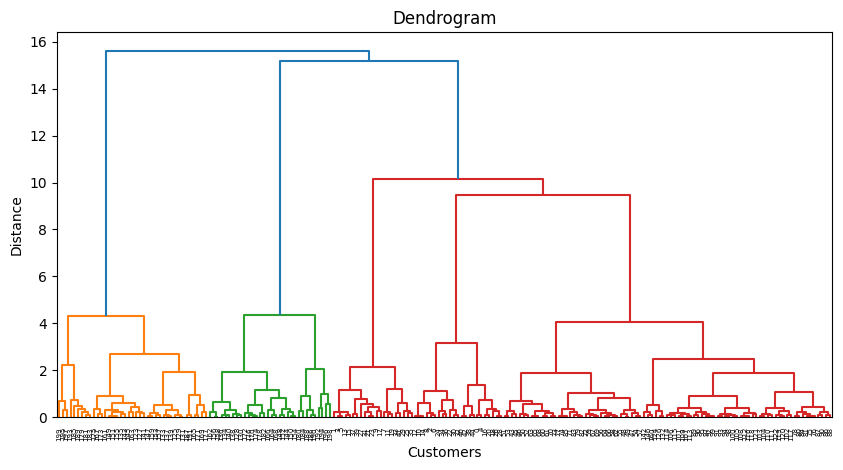

In [9]:
plt.figure(figsize=(10,5))

dendrogram(linkage(X_scaled, method='ward'))

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

In [10]:
model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

clusters = model.fit_predict(X_scaled)

In [11]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


In [12]:
print(df["Cluster"].value_counts())

Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64


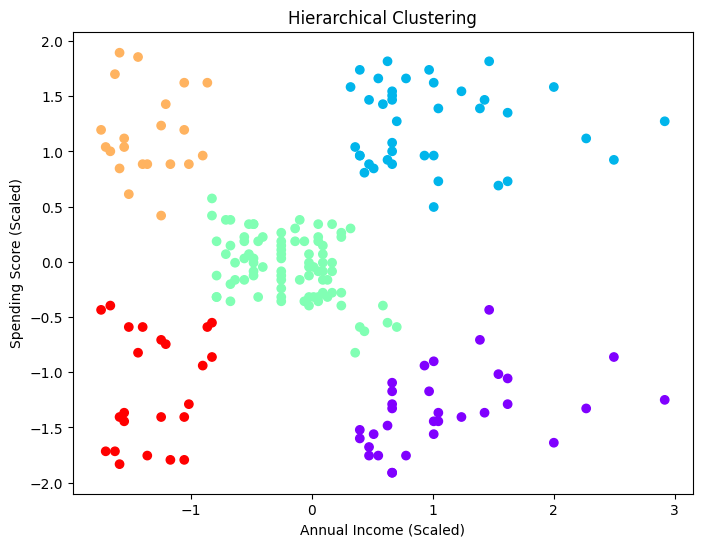

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='rainbow'
)

plt.title("Hierarchical Clustering")

plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")

plt.show()

In [14]:
print(df.groupby("Cluster").mean(numeric_only=True))

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0        166.250000  41.000000           89.406250               15.593750
1        162.000000  32.692308           86.538462               82.128205
2         87.894118  42.482353           55.811765               49.129412
3         22.000000  25.333333           25.095238               80.047619
4         23.000000  45.217391           26.304348               20.913043


In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5538089226688662
